
<div style="background-color:#EFF5FF; padding:14px; border-radius:10px; border-left:8px solid #009E91;">

<h2 style="margin-bottom:0;"><b>Text Mining - Final Project</b></h2>
<h2 style="margin-bottom:0;"><b>Notebook 2: Data Exploration and Preprocessing</b></h2>


<h3 style="margin-top:5px; color:#009E91;;"><b>"Decoding the Rhythms of Emotion: A Sentimental Journey Through Music Genres" </b></h3>

### **1. Imports and Data Loading**

#### **1.1. Imports and Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

#### **1.2. Loading the Data**

For this project, the data is divided into two subsets:
* **Train Dataset ( `train.csv` ):** It contains the song features and our target variable (`tag`, which is the musical genre). We will use this set to build and train our machine-learning models.
* **Test Dataset (`test.csv`):** It also contains the same features apart from `tag`. We will use our final model to predict the genres for this unseen data.

**Train Dataset**

In [2]:
train_dataset = pd.read_csv('./Datasets/train.csv', index_col = 'id')
train_dataset.head()

,title,tag,artist,year,views,features,lyrics
id,,,,,,,
535805,Walk Away,rock,Tony Molina,2013,699,{},When you said you loved me\r\nDid you mean it ...
7519483,Gotta Make It Kid Naruto Rap,rap,Reece Lett,2021,4,{Sl!ck},Kid Naruto Rap\r\n[Hook]\r\nEverybody wants yo...
4892808,​this is what i asked for,pop,Elliot (DNK),2019,389,{},[Verse 1]\r\nPeople tell me I've changed\r\nI ...
1584150,Stealing Hearts,pop,Katie Armiger,2013,126,{},You've been warned about me\r\nDon't try to ge...
7639050,Get Ready,country,John Campbell Munro,1,2,{},[Verse 1]\r\nI can see the end is coming but I...


**Test Dataset**

In [3]:
test_dataset = pd.read_csv('./Datasets/test.csv', index_col = 'id')
test_dataset.head()

,title,artist,year,views,features,lyrics
id,,,,,,
3996359,Like You Do,Jimmie Allen,2018,825,{},[Verse 1]\r\nYour head's on my chest\r\nThis b...
3553166,This Building is Falling Down,The Taxpayers,2009,400,{},Epilogue: A sound off from simple people with ...
2998742,My Private Joy,Dion and The Belmonts,1960,229,{},[Verse 1]\r\nOh well Susie is a doozy with a p...
3993470,Vegan,Yung Kurry,2018,1041,{},Hook\r\nShe a vegan but she eat my meat with n...
5488256,To The Boy I Used To Know,Angelina Cruz,2018,63,{},To the boy I used to know\r\nI wonder how do y...


### **2. Initial Overview**

##### **2.1. Features and Target Variable**

Before moving to the exploratory analysis of our data, it is important to understand what are the variables we will be working with about. The datasets contain the following features:

**Features**
* **`id`**: Unique identifier (currently set as our dataframe index)
* **`title`:** Song title
* **`artist`:** The main artist of the song.
* **`year`:** Year the song was launched in.
* **`views`:** Number of views the song has on an online music service.
* **`features`:** Includes names of collaborating artists, empty otherwise.
* **`lyrics`:** The lyrics of the song. Includes tags for specific sections (e.g. Introduction, Chorus).

**Target Variable**
* **`tag`**: The main musical genre of the song. (This is what our classification model will attempt to predict)

**Unnecessary Columns for Modelling**

We noticed that most of the features we have in our datasets **aren't useful for modelling purposes**. For instance, leaving the `artist` column would make the model 'memorize' that a certain artist is associated with a specific genre (e.g. Eminem = rap), meaning the model would not learn anything about the lyrics themselves. Leaving `views` and `year` also doesn't make sense as they are numerical and do not contribute to the lyrics analysis.

However, while these features won't be used for the final model, **we will keep them in the dataset** rather than dropping them. They are essential to answer some business questions and in the Sentimental Analysis phase.

In [4]:
train_dataset = train_dataset.rename(columns={'lyrics': 'raw_lyrics'})
test_dataset = test_dataset.rename(columns={'lyrics': 'raw_lyrics'}) 

##### **2.2. Dataset Dimensions, Data types and Missing Values**

In this section, we'll check the dimensions of both datasets, data types, and look for missing records to ensure our datasets are reliable and also to identify any immediate cleaning requirements.

In [5]:
# Check the shape of the datasets
print(f"Train dataset shape: {train_dataset.shape}")
print(f"Test dataset shape: {test_dataset.shape}")

Train dataset shape: (134967, 7)
Test dataset shape: (33742, 6)


In [6]:
# Display data types and non-null counts for both datasets
print("\n--- Train Dataset Info ---")
print('**************************')

train_dataset.info()

print("\n--- Test Dataset Info ---")
print('*************************')

test_dataset.info()


--- Train Dataset Info ---
**************************
<class 'pandas.core.frame.DataFrame'>
Index: 134967 entries, 535805 to 6177674
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   title       134965 non-null  object
 1   tag         134967 non-null  object
 2   artist      134967 non-null  object
 3   year        134967 non-null  int64 
 4   views       134967 non-null  int64 
 5   features    134967 non-null  object
 6   raw_lyrics  134967 non-null  object
dtypes: int64(2), object(5)
memory usage: 8.2+ MB

--- Test Dataset Info ---
*************************
<class 'pandas.core.frame.DataFrame'>
Index: 33742 entries, 3996359 to 7747854
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       33742 non-null  object
 1   artist      33742 non-null  object
 2   year        33742 non-null  int64 
 3   views       33742 non-null  int64 
 4   featur

**Observations:**

The training dataset contains 134,967 rows and 7 columns, while the test dataset consists of 33,742 rows and 6 columns (which was expected due to ther target variable).

The `.info()` summary indicates that our features are a mix of numerical (`int64`) and categorical (`object`) formats. Additionally, there are **no significant missing values** across the datasets. (There are 2 missing titles, bu that won't be a problem for our modelling)

Although the `raw_lyrics` column is initially loaded as an `object`, we decided to transform it into a string format so we can prevent future error due to the regex operations.

In [7]:
#change the data type of the 'raw_lyrics' column to string for both datasets, so we can make regex operations.
train_dataset['raw_lyrics'] = train_dataset['raw_lyrics'].astype(str)
test_dataset['raw_lyrics'] = test_dataset['raw_lyrics'].astype(str) 

##### **2.3. Statistical Summary**

In [8]:
train_dataset.describe(include='all')

,title,tag,artist,year,views,features,raw_lyrics
count,134965,134967,134967,134967.000000,1.349670e+05,134967,134967
unique,107703,6,74916,NaN,NaN,18389,134789
top,Intro,pop,Genius English Translations,NaN,NaN,{},Tell us that you would like to have the lyrics...
freq,135,55742,555,NaN,NaN,111928,8
mean,NaN,NaN,NaN,2009.467537,3.413344e+03,NaN,NaN
std,NaN,NaN,NaN,46.287743,4.192449e+04,NaN,NaN
min,NaN,NaN,NaN,1.000000,0.000000e+00,NaN,NaN
25%,NaN,NaN,NaN,2008.000000,2.200000e+01,NaN,NaN
50%,NaN,NaN,NaN,2015.000000,8.900000e+01,NaN,NaN
75%,NaN,NaN,NaN,2019.000000,4.730000e+02,NaN,NaN


**Observations:**

*   **Target Variable (`tag`):** There are 6 unique musical genres, with "pop" being the most dominant class (55,742 occurrences). One of our next steps should be to verify the target variable distribution.
*   **Year Column:** The `year` feature contains obvious entry errors, such as a minimum value of `1`. 
*   **Lyrics:** Out of 134,967 rows, the most frequent entry in `raw_lyrics` is the following string: "Tell us that you would like to have the lyrics...". We will try to verify the existence of duplicate records, if that is the case.
*   **Numerical Distributions:** The `views` column has a massive range (from 0 to over 3.6 million) and a very high standard deviation.
*   **Collaborations:** The majority of the songs do not have featured artists, as the most frequent value in the `features` column is an empty bracket `{}`  with 111,928 occurrences.


##### **2.4.Duplicated Records**

In [9]:
print(f"Train dataset duplicated rows: {train_dataset.duplicated().sum()}")
print(f"Test dataset duplicated rows: {test_dataset.duplicated().sum()}")

Train dataset duplicated rows: 0
Test dataset duplicated rows: 0


**Observations**

We verify that there are no exact duplicates across all columns in our dataset. However, a close look at our statistical summary revealed that only 134,789 out of 134,967 total entries are unique, this means that there are identical lyrics assigned to different tracks.

In [10]:
lyric_counts = train_dataset['raw_lyrics'].value_counts().reset_index()
lyric_counts.columns = ['Lyric Text', 'Frequency']

#filter by the lyrics that appear more than once in the dataset
duplicated_lyrics_table = lyric_counts[lyric_counts['Frequency'] > 1]

print("Top 5 Most Repeated Lyrics")
print(duplicated_lyrics_table.head(5))


Top 5 Most Repeated Lyrics
                                          Lyric Text  Frequency
0  Tell us that you would like to have the lyrics...          8
1  Summary\r\n\r\nYo, what it is? This week hater...          4
2  I got strung up from our loving\r\nI wish you ...          3
3  I am happy to join with you today in what will...          3
4  (The JBeez, the JBeez...)\r\n\r\n10th round\r\...          3


In [11]:
#full text of the most repeated lyric, because it didnt look like a lyric
full_text_1stlyric = lyric_counts.iloc[0]['Lyric Text']
full_text_1stlyric

"Tell us that you would like to have the lyrics of this song. Then we'll make it our highest priority to find these lyrics first!\r\nOr perhaps you can help us out. If you have the lyrics of this song, it would be great if you can submit these. That will definitely help us and the other visitors!"

**Observations**

We confirmed that the top duplicate lyric (8 occurences) is not a genuine song lyrics, but a message asking users to submit missing lyrics which introduces **irrelevant noise into the dataset**.

The best decision would be to **drop** these entries, but that will be performed after, during Section 3. The remaining duplicated represent legitimate lyrics and will be kept in our dataset.

##### **2.5. The 'Year' Column**

As already verified before, we found **obvious entry errors** in the `year` column, such as a minimum value of 1. To better understand the distribution of these entries and see how far they deviate from valid release years, we will plot a boxplot.

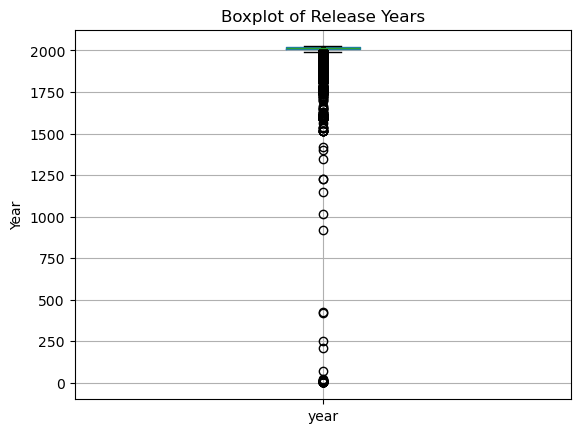

In [13]:
#boxplot to identify
train_dataset.boxplot(column=['year'])
plt.title('Boxplot of Release Years')
plt.ylabel('Year')
plt.show()

In [14]:
train_dataset[train_dataset['year'] < 1900][['year', 'raw_lyrics']]

,year,raw_lyrics
id,,
7639050,1,[Verse 1]\r\nI can see the end is coming but I...
2965307,1879,"[EDITH]\r\nWhat ought we to do,\r\nGentle sist..."
160661,1846,Part The Second\r\n\r\nSNITCHEY AND CRAGGS had...
358526,1867,Paradiso: Canto XXXI\r\n\r\nIn fashion then as...
422212,1867,...
...,...,...
358143,1867,"Purgatorio: Canto XVI\r\n\r\nDarkness of hell,..."
671037,1599,"The Country.\r\n\r\nENTER MACILENTE, WITH A BO..."
238835,1697,"""When Heav'n had overturn'd the Trojan state\r..."


**Decision**

The boxplot clearly highlighted a significant number of **extreme outliers** in the `year` feature, with values dropping all the way down to near zero. After actually verifying the full entries, we discovered that many of these entries are not actually songs, but rather excerpts from classical literature and books.

As it would be very difficult to accurately separate valid lyrics from these literary text because it would introduce errors and noise into our model, we decided to set a **threshold, in this case, the year 1900** and drop all records with a release year prior to 1900.

As established in the previous section regarding duplicated lyrics, we are currently only diagnosing the dataset. The actual removal of these 653 records will be completed in the next section, where we will drop all anomalies to ensure our model trains strictly on valid musical data. 
There are 653 records, which is a very small part of our dataset so we wouldn't lose that many infomration.

### **3. Exploratory Data Analysis (EDA) and Row-Level Filtering (Train Set Only)**

In the previous section, we found some **clear problems** in our dataset, like wrong release years and some duplicate errors. Now, we will clean it up.

It is important to note that we will only drop wors from the **training dataset**. We cannot remove any rows from the test set, because our final model is going to be evaluated on all the original test songs.

We will also analyse our target variable and text lengths to make sure we only train from real lyrics.

#### **3.1. Target Variable Distribution**

It is important to analyse the distribution of our target variable ( `tag` ). Having a heavily imbalanced dataset, which, in this case, means having significantly more songs in some genres than the others, could bias our machine learning model toward the majority classes. The model might try to minimize its error rate failing to properly learn and identify the minority class.

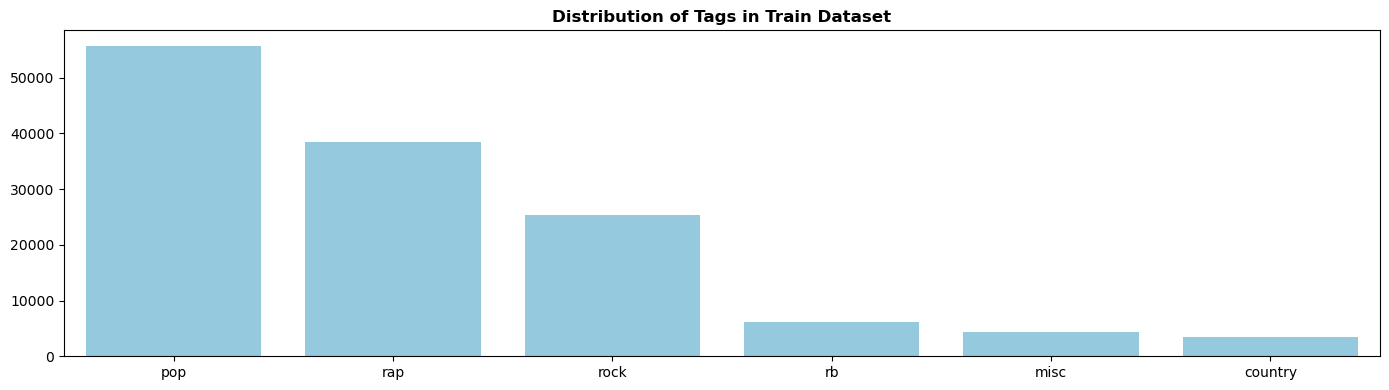

In [27]:
plt.figure(figsize=(14, 4))
sns.countplot(
    data=train_dataset, 
    x='tag', 
    color='skyblue', 
    order=train_dataset['tag'].value_counts().index)

plt.title('Distribution of Tags in Train Dataset', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

##### **Observations:**

As we can observe on the plot above, our dataset is clearly imbalanced being the majority class `pop`and the minority `country`. This is an useful insight because it means that solely relying on '**Accuracy**' as a performance metric could be **misleading**.

#### **3.2. Text Length Analysis**

In this section, we'll analyse with details the **length of the lyrics in our dataset**. Typically, a song ranges between 150 and 600 words. High words count could indicate the presence of book chapters, theatre scripts, blogs etc. We'll begin by calculating the **word count for each song**.

In [28]:
train_dataset['word_count'] = train_dataset['raw_lyrics'].apply(lambda x: len(str(x).split())) #Function to count the number of words in the lyrics

print(train_dataset['word_count'].describe()) #Statistical summary of the word count in the lyrics

count    133420.000000
mean        286.470027
std         181.030195
min          15.000000
25%         158.000000
50%         242.000000
75%         372.000000
max        1400.000000
Name: word_count, dtype: float64


**Observations:**


The stats above reveal a massive disparity between the lyrics' length. While the average is around ~320 words, which was expected already, the maximum value reaches 18221 words. The presence of this entry plus the high standard deviation (~451), confirms us the presence of several outliers. 

##### **3.2.1 Distribution of Word Counts**

To understand the distribution of the lengths and identify potential outliers, we **plot the word counts using both a linear and a logarithmic scale**. The linear scale helps us observe where the vast majority of our data is concentrated, while the logarithmic scale allows us to examine the "long tail" of extreme values that would otherwise remain hidden.

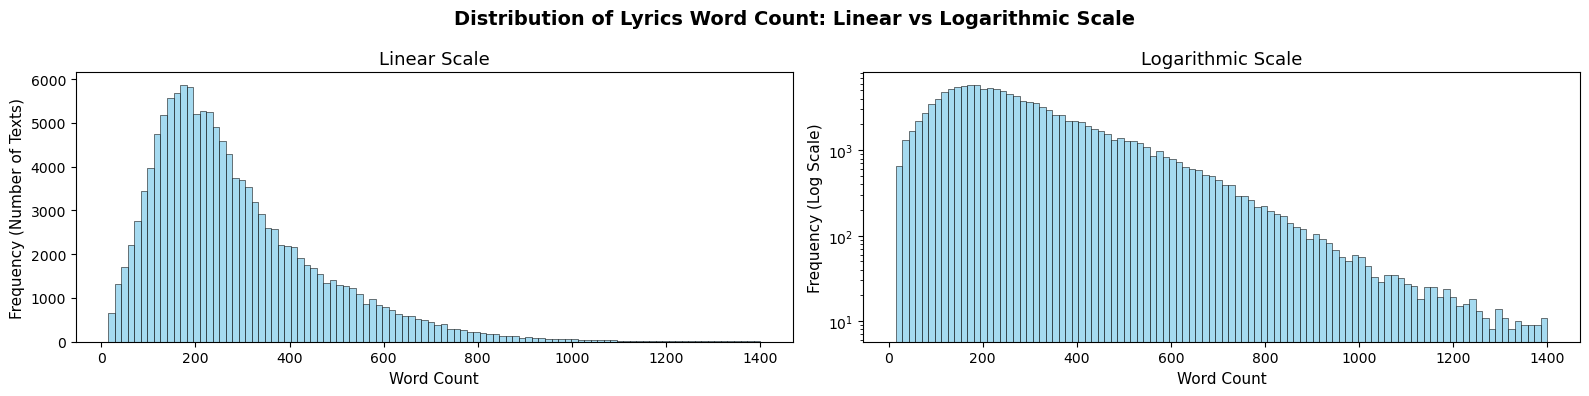

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

#Graph 1: Distribution in Linear Scale
sns.histplot(train_dataset['word_count'], bins=100, color='skyblue', ax=axes[0])
axes[0].set_title('Linear Scale', fontsize=13)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency (Number of Texts)', fontsize=11)

# Graph 2: Distribution in Logarithmic Scale
sns.histplot(train_dataset['word_count'], bins=100, color='skyblue', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Logarithmic Scale', fontsize=13)
axes[1].set_xlabel('Word Count', fontsize=11)
axes[1].set_ylabel('Frequency (Log Scale)', fontsize=11)


plt.suptitle('Distribution of Lyrics Word Count: Linear vs Logarithmic Scale', fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

**Observations:**

The visualization clearly demonstrates the **necessity of outlier removal**. In the linear scale plot, the standard song lengths are heavily compressed into a single spike, "hiding" the outliers. On the other hand, the logarithmic scale shows a long tail of lyrics reaching values up to 17,500 words. 

To ensure the integrity and quality of our model, we need to establish a maximum word count **threshold** to filter out these outliers. We will test a few different threshold values in the next steps to evaluate their impact on the dataset and determine the most optimal limit.

##### **3.2.2 Outliers Removal (Threshold)**


In [30]:
# our threshold, after trying different values, we found that 1400 words is a good threshold.
threshold = 1400

# isolate the outliers based on the threshold
outliers = train_dataset[train_dataset['word_count'] > threshold]
print(f"Number of texts identified as extreme outliers (> {threshold} words): {len(outliers)}\n")
outliers[['word_count', 'raw_lyrics']].iloc[:4]  # Display the first 4 outliers

Number of texts identified as extreme outliers (> 1400 words): 0



,word_count,raw_lyrics
id,,


In [31]:
train_dataset = train_dataset[train_dataset['word_count'] <= threshold]
print(f"Dataset size after applying the {threshold}-word threshold: {len(train_dataset)}")

Dataset size after applying the 1400-word threshold: 133420


We decided to also apply a **minimum threshold** since, after analysing, we found that most of the "lyrics" with too few characters were also not lyrics. After trying different threshold values, 15 was the final choice.

In [32]:
#same processfor the lower threshold
threshold = 15


outliers = train_dataset[train_dataset['word_count'] < threshold]
print(f"Number of texts identified as extreme outliers (< {threshold} words): {len(outliers)}\n")
outliers[['word_count', 'raw_lyrics']].iloc[:4]  # Display the first 4 outliers

Number of texts identified as extreme outliers (< 15 words): 0



,word_count,raw_lyrics
id,,


In [33]:
train_dataset = train_dataset[train_dataset['word_count'] >= threshold]
print(f"Dataset size after applying the {threshold}-word threshold: {len(train_dataset)}")

Dataset size after applying the 15-word threshold: 133420


## **AS PARTES QUE TIRÁMOS DE CIMA**

In [34]:
#remove the most repeated lyric from the train dataset
train_dataset = train_dataset[train_dataset['raw_lyrics'] != full_text_1stlyric]
print(f"Train dataset shape after removing the most repeated lyric: {train_dataset.shape}")

Train dataset shape after removing the most repeated lyric: (133420, 8)


In [35]:
train_dataset = train_dataset[train_dataset['year'] >= 1900]
print(f"Train dataset shape after removing outliers: {train_dataset.shape}")

Train dataset shape after removing outliers: (133420, 8)


#### **3.3. Errors Detection and Removal**

While loading the initial data, we noticed that the `raw_lyrics` column contains various elements such as structural tags (e.g., `[Verse 1]`, `(Chorus)`), standalone structural words and some formatting noise. Since these elements aren't important and will negatively impact the performance of our future NLP models, they need to be remove.

Therefore, this section aims to **identify and remove** this noise early in the data cleaning phase to ensure high-quality input

We will begin by isolating specific examples of the content that needs to be cleaned:

##### **3.2.1. Brackets (Squared or Regular ones)**

In [43]:
regex_brackets = r'\[.*?\]|\(.*?\)'  # Matches text within brackets or parentheses

ex1_brackets = train_dataset[train_dataset['raw_lyrics'].str.contains(regex_brackets, na=False)].index[:4]  # Get the first 4 examples
ex1_brackets = train_dataset['raw_lyrics'].loc[ex1_brackets]
print("--- Example 1: Brackets ---")
print(ex1_brackets)

--- Example 1: Brackets ---
id
7519483    Kid Naruto Rap\r\n[Hook]\r\nEverybody wants yo...
4892808    [Verse 1]\r\nPeople tell me I've changed\r\nI ...
7749704    [YRM Bear]\r\n\r\nSlide through the curb like ...
665689     [Verse 1]\r\nThese eyes locked\r\nI call it\r\...
Name: raw_lyrics, dtype: object


In [44]:
train_dataset['cleaned_lyrics'] = train_dataset['raw_lyrics'].str.replace(regex_brackets, '', regex=True)
print("\n--- Example 1: Brackets Cleaned ---")
print(train_dataset['cleaned_lyrics'].loc[ex1_brackets.index])



--- Example 1: Brackets Cleaned ---
id
7519483    Kid Naruto Rap\r\n\r\nEverybody wants you to h...
4892808    \r\nPeople tell me I've changed\r\nI find it h...
7749704    \r\n\r\nSlide through the curb like toosie\r\n...
665689     \r\nThese eyes locked\r\nI call it\r\nYou can ...
Name: cleaned_lyrics, dtype: object


##### **3.2.2. Standalone Structural Words**

We noticed songs that have those structural words (like 'Chorus' or 'Verse') but without the brackets. Which means they weren't removed before, but as we are not 100% sure about the exact words, we decided to extract the most frequent terms that appeared inside the brackets in our original column(`raw_lyrics`) because it is highy likely that the same words appear without any tags ( e.g. 'Chorus:' isntead of '[Chorus]').

In [45]:
extracted_tags = train_dataset['raw_lyrics'].str.extractall(r'\[(.*?)\]')[0].str.lower()

core_words = extracted_tags.str.extract(r'([a-z]+)')[0] #turns "verse 1" into "verse"

top_words = core_words.value_counts().head(50)


print("--- FinalStructural Words (Filtered) ---")
print(top_words)

--- FinalStructural Words (Filtered) ---
0
verse               116850
chorus               97367
hook                 23816
pre                  20145
bridge               18060
outro                17748
intro                16685
post                  5102
refrain               3575
instrumental          2600
x                     2406
interlude             2192
drop                  1211
guitar                 793
break                  625
spoken                 591
part                   451
repeat                 429
breakdown              429
solo                   391
the                    350
produced               331
sample                 310
all                    303
chrous                 278
i                      247
lil                    215
skit                   195
both                   175
prechorus              159
build                  132
mr                     129
producer               124
man                    118
b                      111
chours      

In [46]:
regex_words_pattern = r'(?im)^\s*(?:' + '|'.join(top_words.index) + r')\b\s*\d*:?\s*$'

ex2_structural_words = train_dataset[train_dataset['cleaned_lyrics'].str.contains(regex_words_pattern, na=False)].index[3:6]
ex2_structural_words = train_dataset['cleaned_lyrics'].loc[ex2_structural_words]
print("--- Example 2: Structural Words ---")    
print(ex2_structural_words)

--- Example 2: Structural Words ---
id
2820836    Song Title: Neombrella\r\n\r\nFirst Verse:\r\n...
984084     Featuring Tha Alkaholiks]\r\nIntro:\r\nTo Japa...
4364772    Verse:\r\n\r\nAll I do is get this money\r\nAl...
Name: cleaned_lyrics, dtype: object


In [47]:
train_dataset['cleaned_lyrics'] = train_dataset['cleaned_lyrics'].str.replace(
    regex_words_pattern, 
    '', 
    flags=re.MULTILINE, 
    regex=True
)

print("\n--- Example 2: Structural Words Cleaned ---")
print(train_dataset['cleaned_lyrics'].loc[ex2_structural_words.index])


--- Example 2: Structural Words Cleaned ---
id
2820836    Song Title: Neombrella\r\n\r\nFirst Verse:\r\n...
984084     Featuring Tha Alkaholiks]\r\n\nTo Japan they l...
4364772    \nAll I do is get this money\r\nAll I do is sh...
Name: cleaned_lyrics, dtype: object


### VER ESTE MARKDOWN

**A Note on Precision vs. Recall in Data Cleaning**

While our strict line-bound regex (`^...$`) successfully removes the vast majority of standalone structural tags (e.g., "Chorus:", "Intro"), it intentionally bypasses complex or heavily annotated tags (e.g., "First Verse:", "Part 1 - Tape Blip"). 

We chose to accept this limitation to prioritize data integrity. Attempting to capture every irregular tag format via hardcoded rules significantly increases the risk of false positives—inadvertently deleting genuine song lyrics. The remaining noise is statistically negligible and will not heavily impact our modeling phase.

##### **3.2.3. New Line Characters**

In [50]:
regex_newlines = r'\n|\r'  # Matches newline characters

ex3_newlines = train_dataset[train_dataset['cleaned_lyrics'].str.contains(regex_newlines, na=False)].index[:4]  # Get the first 4 examples
ex3_newlines = train_dataset['cleaned_lyrics'].loc[ex3_newlines]
print("--- Example 3: Newlines ---")
print(ex3_newlines)

--- Example 3: Newlines ---
id
535805     When you said you loved me\r Did you mean it t...
7519483    Kid Naruto Rap\r \r Everybody wants you to hur...
4892808    \r People tell me I've changed\r I find it har...
1584150    You've been warned about me\r Don't try to get...
Name: cleaned_lyrics, dtype: object


In [51]:
train_dataset['cleaned_lyrics'] = train_dataset['cleaned_lyrics'].str.replace(regex_newlines, ' ', regex=True)

print("\n--- Example 3: Newlines Cleaned ---")
print(train_dataset['cleaned_lyrics'].loc[ex3_newlines.index])


--- Example 3: Newlines Cleaned ---
id
535805     When you said you loved me  Did you mean it th...
7519483    Kid Naruto Rap    Everybody wants you to hurt ...
4892808      People tell me I've changed  I find it hard ...
1584150    You've been warned about me  Don't try to get ...
Name: cleaned_lyrics, dtype: object


##### **3.2.4. Emojis**

In [52]:
regex_emojis = r'[\u2600-\u27FF]|[\U00010000-\U0010ffff]'

ex4_emojis = train_dataset['cleaned_lyrics'].str.contains(regex_emojis, regex=True, na=False)
ex4_emojis_head3 = train_dataset[ex4_emojis].head(3).index

print("--- Example 4: Emojis ---")
print(train_dataset['cleaned_lyrics'].loc[ex4_emojis_head3])


print(f'\n There are {ex4_emojis.sum()} songs with emojis in the lyrics.')

--- Example 4: Emojis ---
id
99017      In the field of economics, the commodity value...
6664020    Body Bagy        Now you stuck in a hole, -tri...
3201434    Colder than Alaska bars that make you think yo...
Name: cleaned_lyrics, dtype: object

 There are 107 songs with emojis in the lyrics.


**Decision**

While some rows containing emojis are valid lyrics, our analysis revealed that emojis often act as a strong indicator of non-musical text. Given that only 113 rows show this behavior, which is a statistically insignificant portion of our dataset, we chose to drop these rows entirely. 

In [53]:
train_dataset = train_dataset[~ex4_emojis].reset_index(drop=True)

print(f"\nNew dataset size after dropping rows: {len(train_dataset)}")


New dataset size after dropping rows: 133313


##### **3.2.5. Mentions and URL's**

In [54]:
regex_mentions_urls = r'@[A-Za-z0-9_]+|https?://\S+|www\.\S+'

ex5_mentions_urls = train_dataset['cleaned_lyrics'].str.contains(regex_mentions_urls, regex=True, na=False)
ex5_head7 = train_dataset[ex5_mentions_urls].head(7).index

print("--- Example 5: Mentions & URLs ---")
print(train_dataset['cleaned_lyrics'].loc[ex5_head7])

print(f"\nTotal rows with mentions or URLs: {ex5_mentions_urls.sum()}")

--- Example 5: Mentions & URLs ---
1342    What is a Transcriber?A Genius Transcriber is ...
1761    2005Don't Lie  2006All That I Got    Glamorous...
4044    It's unremarkable that rivals now comprehend S...
4845    Hey, im sorry to bother you but i was just won...
5648    By Ignatiy Vishnevetsky@vishnevetsky  Mar 12, ...
5943    How do you do I have missed you since you went...
5954    leave a comment down below if you would like t...
Name: cleaned_lyrics, dtype: object

Total rows with mentions or URLs: 195


**Decision**

Similarly to the emoji, the presence of user mentions and specially hyperlinks strongly correlates with non-music with an even higher correlation than the emojis one. These are typically promotional spam, user comments etc.. Since there are only 217 rows (again a statistically insignificant portion of the dataset), we will drop these rows to preserve the quality of our model.

In [55]:
train_dataset = train_dataset[~ex5_mentions_urls].reset_index(drop=True)

print(f"\nNew dataset size after dropping rows: {len(train_dataset)}")


New dataset size after dropping rows: 133118


##### **3.2.6. Dates (Journal Entries)**

In [56]:
# Matches variations like: 12-05-22, 2022/05/12, 1-2-2000, 01/05/99
regex_dates = (r'^\b(?:'
    r'(?:0?[1-9]|[12]\d|3[01])[-](?:0?[1-9]|1[0-2])[-](?:19|20)?\d{2}|' # DD-MM-YY or DD-MM-YYYY
    r'(?:0?[1-9]|1[0-2])[-](?:0?[1-9]|[12]\d|3[01])[-](?:19|20)?\d{2}|' # MM-DD-YY or MM-DD-YYYY
    r'(?:19|20)\d{2}[-](?:0?[1-9]|1[0-2])[-](?:0?[1-9]|[12]\d|3[01])'   # YYYY-MM-DD
    r')\b')

ex6_dates = train_dataset['cleaned_lyrics'].str.contains(regex_dates, regex=True, na=False)
print(f"Rows with likely diary entries: {ex6_dates.sum()}")


print("\n--- Example 6: Diary Entries / ---")
print(train_dataset['cleaned_lyrics'].loc[ex6_dates])

Rows with likely diary entries: 13

--- Example 6: Diary Entries / ---
130       11-11-13  I read about the Mexican actress Bia...
26710     10-7-13  I read chapter 5 in the book i am rea...
34895     12-2-2013  Today i read about the first laught...
41415     10-07-13  A little boys grandfather died. When...
60621     9-16-13    I read about how Darcy school life ...
71770     12-10-13  Former NBA star Lamar Odom gets off ...
72280     9-9-2013  I read A Matter Of Trust by Anne Sch...
80984     10-28-13  The next day during training Tris mu...
89154     9-30-13  Buffy The Vampire Slayer    I'm into ...
91109     9-23-2013    "It's Global Warming, Stupid" is ...
98160     10-28-13  Chris Brown got arrested for getting...
117929    11-18-2013  Today i read about this foundation...
126528    10-28-13 Chris Brown was expected to appear in...
Name: cleaned_lyrics, dtype: object


In [57]:
train_dataset = train_dataset[~ex6_dates].reset_index(drop=True)
print(f"Dataset size after cleaning: {len(train_dataset)}")

Dataset size after cleaning: 133105


**Decision**
The decision to drop all this 13 entries was very straight forward as we're 100% sure that all of them journal entries with zero importance to our model

In [ ]:
def clean_lyrics_pipeline(text):